# Разведочный анализ

In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv
import clickhouse_connect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [3]:
# Определяем путь к .env файлу относительно текущего ноутбука
env_path = Path.cwd().parent / 'infrastructure' / '.env'
# Загружаем переменные из указанного пути
if env_path.exists():
    load_dotenv(dotenv_path=env_path)
    print(f"Конфигурация загружена из: {env_path}")
else:
    print(f"Файл .env не найден по пути: {env_path}")

Конфигурация загружена из: /home/andrew/oncology_fhir_analytics/infrastructure/.env


In [4]:
# Подключаемся к ClickHouse
client = clickhouse_connect.get_client(
    host='localhost',
    port=8123,
    username=os.getenv('CLICKHOUSE_USER', 'default'),
    password=os.getenv('CLICKHOUSE_PASSWORD', ''),
    database=os.getenv('CLICKHOUSE_DB', 'default')
)

def query_df(sql):
    return client.query_df(sql)

print("Подключение установлено.")

Подключение установлено.


## Анализ пациентов

In [46]:
df_patients = query_df("""
SELECT 
    gender, 
    race, 
    marital_status,
    dateDiff('year', birth_date, today()) as age,                  
    is_deceased
FROM oncology.patients
""")

In [47]:
df_patients.head()

,gender,race,marital_status,age,is_deceased
0,male,White,Married,90,0
1,female,White,Married,89,1
2,female,White,Married,56,0
3,female,White,Widowed,84,1
4,female,White,Married,88,1


In [31]:
print("Основные статистики возраста:")
df_patients['age'].describe()

Основные статистики возраста:


count      10673.0
mean     76.106343
std      12.040693
min           45.0
25%           68.0
50%           80.0
75%           86.0
max           90.0
Name: age, dtype: Float64

In [30]:
print("Распределение по полу:")
gender_counts = df_patients['gender'].value_counts().reset_index()
total = gender_counts['count'].sum()
gender_counts['percentage'] = (gender_counts['count'] / total * 100).round(2)
gender_counts

Распределение по полу:


,gender,count,percentage
0,female,5457,51.13
1,male,5216,48.87


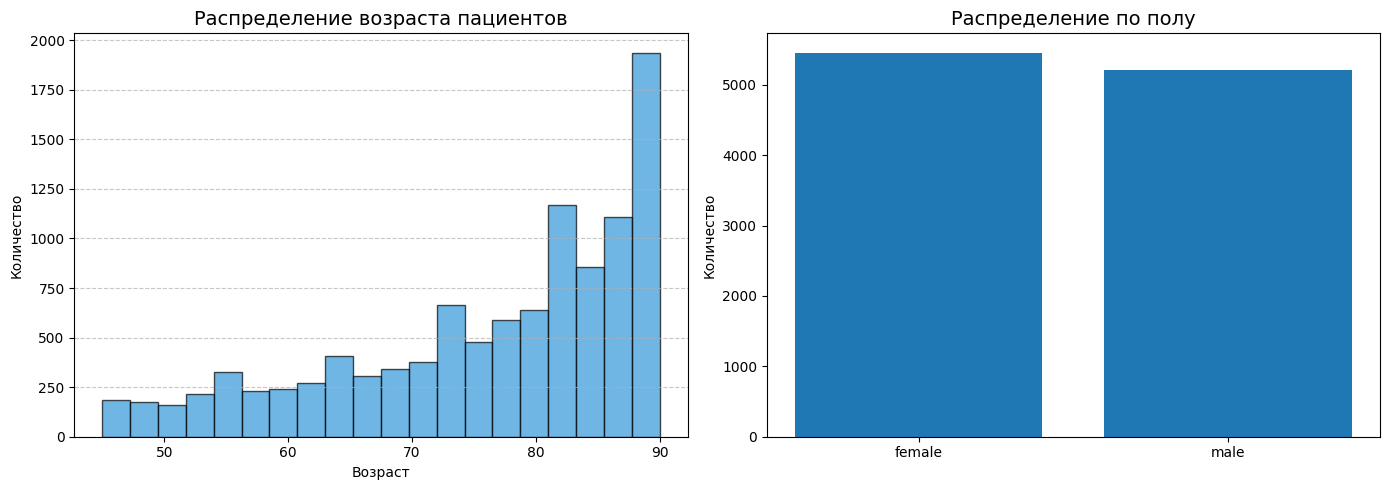

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма возраста
ax1.hist(df_patients['age'], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
ax1.set_title('Распределение возраста пациентов', fontsize=14)
ax1.set_xlabel('Возраст')
ax1.set_ylabel('Количество')
ax1.grid(axis='y', linestyle='--', alpha=0.7)
# Столбчатая диаграмма пола
gender_counts = df_patients['gender'].value_counts()
ax2.bar(gender_counts.index, gender_counts.values)
ax2.set_title('Распределение по полу', fontsize=14)
ax2.set_ylabel('Количество')

plt.tight_layout()
plt.show()

In [50]:
print("Расределение по выживаемости:")
status_counts = df_patients['is_deceased'].value_counts().reset_index()
total = status_counts['count'].sum()
status_counts['percentage'] = (status_counts['count'] / total * 100).round(2)
status_counts

Расределение по выживаемости:


,is_deceased,count,percentage
0,0,6046,56.65
1,1,4627,43.35


In [51]:
print("Доля в группе пациентов представителей разных расс:")
race_counts = df_patients['race'].value_counts().reset_index()
total = race_counts['count'].sum()
race_counts['percentage'] = (race_counts['count'] / total * 100).round(2)
race_counts

Доля в группе пациентов представителей разных расс:


,race,count,percentage
0,White,8824,82.68
1,Black or African American,883,8.27
2,Asian,683,6.4
3,Other,137,1.28
4,Native Hawaiian or Other Pacific Islander,100,0.94
5,American Indian or Alaska Native,46,0.43


In [97]:
# Статиситка смертности по полу
gender_death_ct = pd.crosstab(df_patients['gender'], df_patients['is_deceased'])
gender_death_ct.columns = ['Alive', 'Deceased']
gender_death_ct['Mortality Rate (%)'] = (gender_death_ct['Deceased'] / 
                                         (gender_death_ct['Alive'] + gender_death_ct['Deceased']) * 100).round(2)

print("Статистика смертности по полу:")
gender_death_ct

Статистика смертности по полу:


,Alive,Deceased,Mortality Rate (%)
gender,,,
female,3122,2335,42.79
male,2924,2292,43.94


In [57]:
print("Распределение по семейному положению:")
marital_status_counts = df_patients['marital_status'].value_counts().reset_index()
total = marital_status_counts['count'].sum()
marital_status_counts['percentage'] = (marital_status_counts['count'] / total * 100).round(2)
marital_status_counts

Распределение по семейному положению:


,marital_status,count,percentage
0,Married,5844,54.75
1,Never Married,2181,20.43
2,Divorced,1922,18.01
3,Widowed,726,6.8


In [96]:
# Статиситка смертности по семейному положению
marital_status_death_ct = pd.crosstab(df_patients['marital_status'], df_patients['is_deceased'])
marital_status_death_ct.columns = ['Alive', 'Deceased']
marital_status_death_ct['Mortality Rate (%)'] = (marital_status_death_ct['Deceased'] / 
                                         (marital_status_death_ct['Alive'] + marital_status_death_ct['Deceased']) * 100).round(2)

print("Статистика смертности по семейному положению:")
marital_status_death_ct

Статистика смертности по семейному положению:


,Alive,Deceased,Mortality Rate (%)
marital_status,,,
Divorced,1109,813,42.30
Married,3313,2531,43.31
Never Married,1226,955,43.79
Widowed,398,328,45.18


## Анализ диагнозов

In [72]:
df_conditions = query_df("""
SELECT 
    patient_id,
    code, 
    display, 
FROM oncology.conditions
""")
df_conditions.head()

,patient_id,code,display
0,b9b9d211-f520-aea1-0098-86b3fb2e73c2,68496003,Polyp of colon (disorder)
1,4734766a-ddfc-f672-00c7-9506bb7a7bd7,68496003,Polyp of colon (disorder)
2,4734766a-ddfc-f672-00c7-9506bb7a7bd7,68496003,Polyp of colon (disorder)
3,c5883ec8-43f9-36de-00e9-2242b44d23c9,68496003,Polyp of colon (disorder)
4,10a81c04-78ef-1c0a-0117-b2f85d6cdaa1,68496003,Polyp of colon (disorder)


In [73]:
print("Распределение диагнозов:")
condition_counts = df_conditions[['code','display']].value_counts().reset_index()
total = condition_counts['count'].sum()
condition_counts['percentage'] = (condition_counts['count'] / total * 100).round(2)
condition_counts

Распределение диагнозов:


,code,display,count,percentage
0,68496003,Polyp of colon (disorder),8024,37.26
1,713197008,Recurrent rectal polyp (disorder),3927,18.23
2,271737000,Anemia (disorder),3195,14.83
3,109838007,Overlapping malignant neoplasm of colon (disor...,2404,11.16
4,363406005,Malignant neoplasm of colon (disorder),2136,9.92
5,93761005,Primary malignant neoplasm of colon (disorder),1133,5.26
6,236077008,Protracted diarrhea (finding),344,1.60
7,6072007,Bleeding from anus (disorder),344,1.60
8,94260004,Metastatic malignant neoplasm to colon (disorder),30,0.14


In [74]:
target_codes = ['68496003', '713197008', '93761005', '109838007', '363406005', '94260004']

df_cond_stats = query_df(f"""
SELECT 
    code, 
    display, 
    count() as cnt,
    count(DISTINCT patient_id) as unique_patients
FROM oncology.conditions
WHERE code IN {tuple(target_codes)}
GROUP BY code, display
ORDER BY cnt DESC
""")
print("Статистика по целевым кодам SNOMED:")
df_cond_stats

Статистика по целевым кодам SNOMED:


,code,display,cnt,unique_patients
0,68496003,Polyp of colon (disorder),8024,6452
1,713197008,Recurrent rectal polyp (disorder),3927,3842
2,109838007,Overlapping malignant neoplasm of colon (disor...,2404,2404
3,363406005,Malignant neoplasm of colon (disorder),2136,2136
4,93761005,Primary malignant neoplasm of colon (disorder),1133,1133
5,94260004,Metastatic malignant neoplasm to colon (disorder),30,30


## Анализ витрины объединенных данных patients и conditions

### Создание витрины

In [78]:
sql_mart = """
WITH patient_groups AS (
    SELECT 
        patient_id,
        -- Определяем категорию ТОЛЬКО для тех, кто есть в таблице conditions
        multiIf(
            hasAny(groupArray(code), ['93761005', '109838007', '363406005', '94260004']), 'CRC',
            hasAny(groupArray(code), ['68496003', '713197008']), 'Polyp',
            'Control'
        ) as category
    FROM oncology.conditions
    GROUP BY patient_id
)
SELECT 
    p.patient_id,
    p.gender,
    p.race,
    dateDiff('year', p.birth_date, today()) as age,
    marital_status,
    p.is_deceased,
    -- Если в g.category пусто или NULL, пишем 'Control'
    if(g.category = '' OR isNull(g.category), 'Control', g.category) as patient_group,
    -- Превращаем NULL в 0
    COALESCE((SELECT count() FROM oncology.observations o WHERE o.patient_id = p.patient_id), 0) as obs_count,
    COALESCE((SELECT count() FROM oncology.procedures pr WHERE pr.patient_id = p.patient_id), 0) as proc_count
FROM oncology.patients p
LEFT JOIN patient_groups g ON p.patient_id = g.patient_id
"""

df_mart = query_df(sql_mart)
print(f"Витрина загружена: {df_mart.shape[0]} пациентов")

Витрина загружена: 10673 пациентов


In [79]:
df_mart.head()

,patient_id,gender,race,age,marital_status,is_deceased,patient_group,obs_count,proc_count
0,81c3347d-4bf5-82bd-7804-dfd8c3644328,male,White,74,Divorced,0,Control,0,5
1,766c3960-68c7-6da4-0267-96fca4e155c3,male,Black or African American,90,Married,1,CRC,173,18
2,79155e97-0493-cd03-91d1-f5d212cc3f93,female,White,53,Married,0,CRC,183,17
3,10027f14-b0d7-c853-9888-22eb9b8d6659,male,White,85,Married,1,CRC,16,15
4,bcc59537-9e5b-3f9d-e97b-790cd6277aa6,male,White,72,Divorced,1,CRC,186,19


In [82]:
df_mart.describe()

,age,is_deceased,obs_count,proc_count
count,10673.0,10673.000000,10673.000000,10673.000000
mean,76.106343,0.433524,52.566289,9.340860
std,12.040693,0.495584,78.495447,7.130096
min,45.0,0.000000,0.000000,0.000000
25%,68.0,0.000000,1.000000,3.000000
50%,80.0,0.000000,4.000000,9.000000
75%,86.0,1.000000,172.000000,15.000000
max,90.0,1.000000,190.000000,30.000000


Распределение диагнозов по группам

In [77]:
print("Рапределение по группам диагнозов:")
group_counts = df_mart['patient_group'].value_counts(dropna=False).reset_index()
total = group_counts['count'].sum()
group_counts['percentage'] = (group_counts['count'] / total * 100).round(2)
group_counts

Рапределение по группам диагнозов:


,patient_group,count,percentage
0,CRC,5703,53.43
1,Control,3877,36.33
2,Polyp,1093,10.24


In [110]:
print("Распределение возраста в клинических группах")
df_mart.groupby('patient_group')['age'].describe()

Распределение возраста в клинических группах


,count,mean,std,min,25%,50%,75%,max
patient_group,,,,,,,,
CRC,5703.0,79.487989,9.150759,46.0,74.0,82.0,87.0,90.0
Control,3877.0,70.260511,14.042017,45.0,57.0,72.0,83.0,90.0
Polyp,1093.0,79.197621,9.44074,51.0,73.0,82.0,87.0,90.0


/tmp/ipykernel_11565/3132430872.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['Control', 'Polyp', 'CRC'], patch_artist=True,


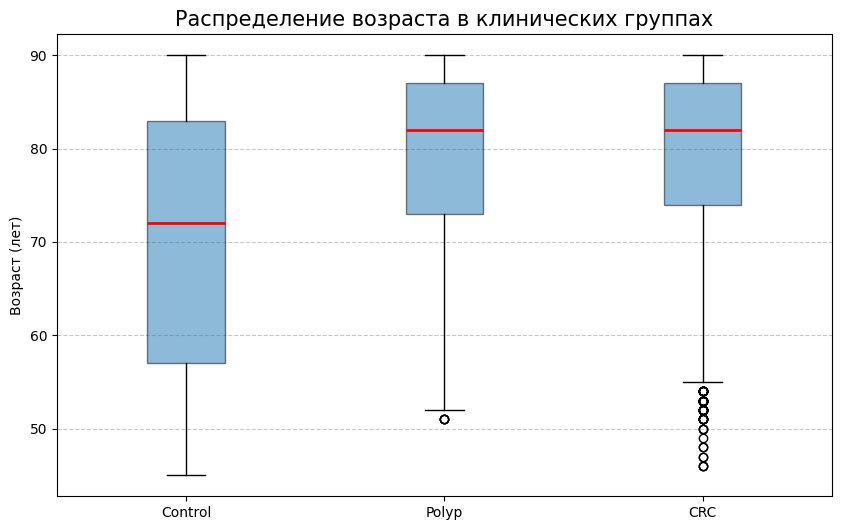

In [111]:
plt.figure(figsize=(10, 6))

data = [
    df_mart[df_mart['patient_group'] == 'Control']['age'],
    df_mart[df_mart['patient_group'] == 'Polyp']['age'],
    df_mart[df_mart['patient_group'] == 'CRC']['age']
]

plt.boxplot(data, labels=['Control', 'Polyp', 'CRC'], patch_artist=True,
            boxprops=dict(alpha=0.5),
            medianprops=dict(color='red', linewidth=2))

plt.title('Распределение возраста в клинических группах', fontsize=15)
plt.ylabel('Возраст (лет)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [112]:
# Статистика смертности в клинических группах
death_group_ct = pd.crosstab(df_mart['patient_group'], df_mart['is_deceased'])
death_group_ct.columns = ['Alive', 'Deceased']
death_group_ct['Mortality Rate (%)'] = (death_group_ct['Deceased'] / 
                                         (death_group_ct['Alive'] + death_group_ct['Deceased']) * 100).round(2)
print("Статистика смертности в клинических группах")
death_group_ct

Статистика смертности в клинических группах


,Alive,Deceased,Mortality Rate (%)
patient_group,,,
CRC,2819,2884,50.57
Control,2571,1306,33.69
Polyp,656,437,39.98


In [113]:
avg_metrics = df_mart.groupby('patient_group')[['obs_count', 'proc_count']].mean()
print("Среднее количество анализов и процедур на одного пациента в группах")
avg_metrics

Среднее количество анализов и процедур на одного пациента в группах


,obs_count,proc_count
patient_group,,
CRC,97.569876,14.586007
Control,0.336858,1.758834
Polyp,3.012809,8.867338
